In [31]:
import pandas as pd

In [32]:
df = pd.read_csv('./results/cleaned_shipment_classification_dataset.csv')

In [33]:
# columns_to_drop = ['receipt_date', 'shipment_delay_days', 'shipment_terms','vessel__voyage',]
# df = df.drop(columns=columns_to_drop)

In [34]:
df.columns

Index(['quantity_in', 'bill_date', 'due_date', 'eta', 'seal', 'customs_broker',
       'receipt_date', 'ocean_freight', 'yield_percentage',
       'shipment_classified'],
      dtype='object')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1785 entries, 0 to 1784
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   quantity_in          1785 non-null   float64
 1   bill_date            1785 non-null   object 
 2   due_date             1785 non-null   object 
 3   eta                  1785 non-null   object 
 4   seal                 1785 non-null   object 
 5   customs_broker       1785 non-null   object 
 6   receipt_date         1785 non-null   object 
 7   ocean_freight        1785 non-null   float64
 8   yield_percentage     1785 non-null   float64
 9   shipment_classified  1785 non-null   object 
dtypes: float64(3), object(7)
memory usage: 139.6+ KB


In [36]:
df.head(n=5)

,quantity_in,bill_date,due_date,eta,seal,customs_broker,receipt_date,ocean_freight,yield_percentage,shipment_classified
0,35280.0,2025-10-09,2025-10-09,2025-10-06,M0697994,Pegasus Shipping Inc.,2025-10-09,5800.00,78.0,on_time
1,34020.0,2025-10-07,2025-10-07,2025-10-06,ML-IN2658867,Pegasus Shipping Inc.,2025-10-07,6900.00,91.0,on_time
2,35280.0,2025-10-07,2025-10-07,2025-10-03,EMCJDB9494,New York Customs Brokers Inc,2025-10-07,4218.00,105.0,on_time
3,38000.0,2025-10-08,2025-10-18,2025-10-06,M0675053,Pegasus Shipping Inc.,2025-10-08,7100.64,0.0,on_time
4,34020.0,2025-10-07,2025-10-07,2025-10-06,ML-IN2424331,Pegasus Shipping Inc.,2025-10-07,7300.00,78.0,on_time


In [37]:
# df['inventory'].value_counts()

<Axes: title={'center': 'Shipment Status Distribution'}, xlabel='shipment_classified'>

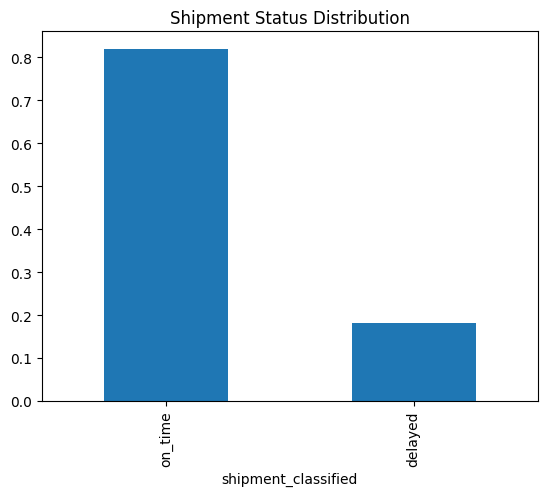

In [38]:
# Distribution of shipment classification
df['shipment_classified'].value_counts(normalize=True).plot(kind='bar', title='Shipment Status Distribution')

In [39]:
# df['fda_status'].value_counts().plot(kind='bar', title='FDA Status Distribution')

In [40]:
# df['coo'].value_counts().plot(kind='bar', title='COO Distribution')

In [41]:
# df['inventory'].value_counts().plot(kind='bar', title='Inventory Distribution')

In [42]:
# df['payment_terms'].value_counts().plot(kind='bar', title='FDA Status Distribution')

In [43]:
# df['discount'].hist(grid=False, bins=30)

In [44]:
# seems need to remove sku 
# need to do feature engineering

In [45]:
# df['vessel__voyage'].value_counts().plot(kind='bar', title='Vessel Voyage Distribution')

In [46]:
# df['consignee'].value_counts().plot(kind='bar', title='Consignee Distribution')

<Axes: xlabel='customs_broker'>

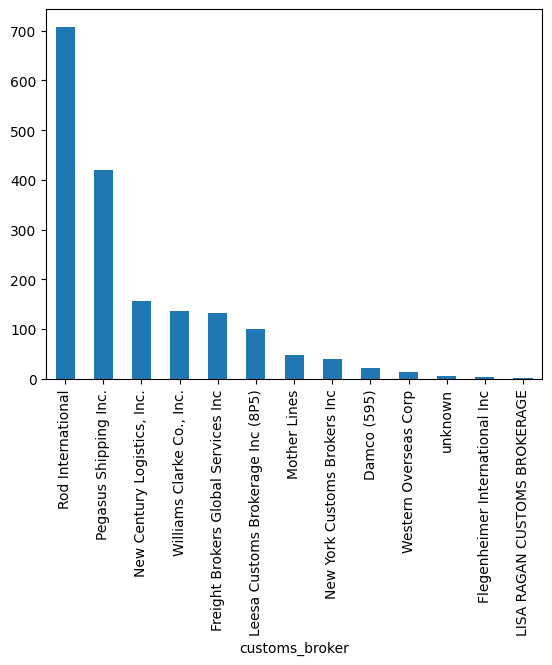

In [47]:
df['customs_broker'].value_counts().plot(kind='bar')

In [48]:
df.columns

Index(['quantity_in', 'bill_date', 'due_date', 'eta', 'seal', 'customs_broker',
       'receipt_date', 'ocean_freight', 'yield_percentage',
       'shipment_classified'],
      dtype='object')

In [49]:
import numpy as np
df.select_dtypes(include=[np.number]).corr()

,quantity_in,ocean_freight,yield_percentage
quantity_in,1.000000,-0.068060,-0.028491
ocean_freight,-0.068060,1.000000,-0.181615
yield_percentage,-0.028491,-0.181615,1.000000


In [50]:
# df['fda_status'].value_counts()

In [51]:
# df['bill_item_size'].value_counts().plot(kind='bar', title='Bill Item Size Distribution')

In [52]:
# df['bill_type'].value_counts().plot(kind='bar', title='Bill Type Distribution')

In [53]:
# df['bill_status'].value_counts().plot(kind='bar', title='Bill Item Size Distribution')

In [54]:
# df['bill_type'].value_counts().plot(kind='bar', title='Bill Item Size Distribution')

In [55]:
# df['status'].value_counts()

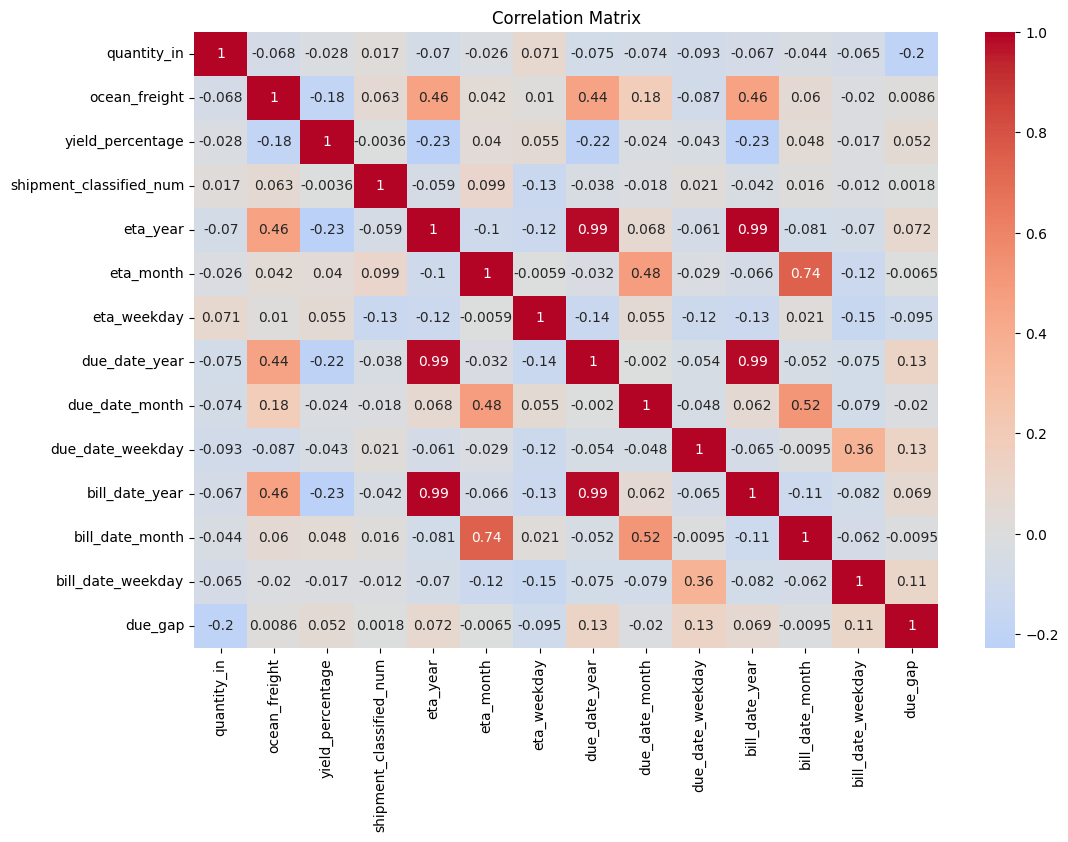

shipment_classified_num    1.000000
eta_month                  0.098704
ocean_freight              0.062978
due_date_weekday           0.021216
quantity_in                0.017482
bill_date_month            0.016249
due_gap                    0.001789
yield_percentage          -0.003606
bill_date_weekday         -0.012227
due_date_month            -0.018012
due_date_year             -0.037928
bill_date_year            -0.042396
eta_year                  -0.058644
eta_weekday               -0.132620
Name: shipment_classified_num, dtype: float64


In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Assume df is your DataFrame; replace with pd.read_csv('your_file.csv')
# df = pd.read_csv('your_file.csv')

# Convert inventory to numeric
# df['inventory_num'] = pd.to_numeric(df['inventory'], errors='coerce')
# df.drop('inventory', axis=1, inplace=True)  # Drop original if needed

# One-hot encode categoricals: fda_status and coo
# df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded = df.copy()

# Binary encode target: Map shipment_classified to 0/1 ('delayed'=1, 'on_time'=0)
df_encoded['shipment_classified_num'] = df_encoded['shipment_classified'].map({'delayed': 1, 'on_time': 0})
df_encoded.drop('shipment_classified', axis=1, inplace=True)

date_columns = ['eta','due_date','bill_date',]  # 'receipt_date' will only be placed after shipment is received
for col in date_columns:
    df_encoded[col] = pd.to_datetime(df_encoded[col], errors='coerce')

# --- 5️⃣ Create derived time features ---
for col in date_columns:
  df_encoded[f'{col}_year'] = df_encoded[f'{col}'].dt.year
  df_encoded[f'{col}_month'] = df_encoded[f'{col}'].dt.month
  df[f'{col}_day'] = df_encoded[col].dt.day
  df_encoded[f'{col}_weekday'] = df_encoded[f'{col}'].dt.weekday

df_encoded['due_gap'] = (pd.to_datetime(df_encoded['due_date']) - pd.to_datetime(df_encoded['bill_date'])).dt.days

df_encoded.drop(date_columns + ['receipt_date'], axis=1, inplace=True)

# Select numerical columns for correlation
numerical_cols = df_encoded.select_dtypes(include=[np.number]).columns
corr_matrix = df_encoded[numerical_cols].corr()

# Visualize correlation heatmap (optional)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Print correlations with target
print(corr_matrix['shipment_classified_num'].sort_values(ascending=False))

In [57]:
# df['scac'].value_counts().plot(kind='bar', title='SCAC Distribution')

In [58]:
# df['item_cases'].value_counts()

In [59]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Copy dataframe
df_corr = df.copy()

# Encode categorical columns
le = LabelEncoder()
for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

# Compute correlation matrix
corr_matrix = df_corr.corr()

# Correlation with target
target_corr = corr_matrix['shipment_classified'].sort_values(ascending=False)

print(target_corr)


shipment_classified    1.000000
due_date_day           0.046375
eta_day                0.034546
eta                    0.024847
bill_date_day          0.024837
receipt_date           0.017226
bill_date              0.016711
seal                   0.013964
due_date               0.011305
yield_percentage       0.003606
quantity_in           -0.017482
ocean_freight         -0.062978
customs_broker        -0.103227
Name: shipment_classified, dtype: float64


In [60]:
import numpy as np
import scipy.stats as ss

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

for col in df.select_dtypes('object').columns:
    if col != 'shipment_classified':
        print(f"{col}: {cramers_v(df[col], df['shipment_classified']):.3f}")


bill_date: 0.575
due_date: 0.529
eta: 0.632
seal: 0.208
customs_broker: 0.137
receipt_date: 0.594
